In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
deaths_df = pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_global.csv')
deaths = deaths_df.groupby('Country/Region').sum()
del deaths['Lat']
del deaths['Long']
cz = deaths.loc['Czechia'].tail(30)
cz
# deaths.loc['Czechia'].plot()

1/24/23    42287
1/25/23    42293
1/26/23    42296
1/27/23    42301
1/28/23    42302
1/29/23    42303
1/30/23    42304
1/31/23    42307
2/1/23     42312
2/2/23     42319
2/3/23     42323
2/4/23     42325
2/5/23     42326
2/6/23     42327
2/7/23     42329
2/8/23     42334
2/9/23     42338
2/10/23    42344
2/11/23    42346
2/12/23    42348
2/13/23    42348
2/14/23    42358
2/15/23    42361
2/16/23    42368
2/17/23    42369
2/18/23    42373
2/19/23    42375
2/20/23    42380
2/21/23    42391
2/22/23    42397
Name: Czechia, dtype: int64

In [3]:
d = deaths.T
increments = d.rolling(window=2).apply(lambda x: x.iloc[-1] - x.iloc[0])
i = increments.Czechia.tail(14)
i

2/9/23      4.0
2/10/23     6.0
2/11/23     2.0
2/12/23     2.0
2/13/23     0.0
2/14/23    10.0
2/15/23     3.0
2/16/23     7.0
2/17/23     1.0
2/18/23     4.0
2/19/23     2.0
2/20/23     5.0
2/21/23    11.0
2/22/23     6.0
Name: Czechia, dtype: float64

<AxesSubplot:>

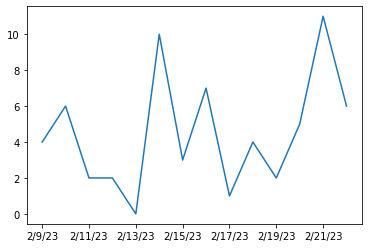

In [4]:
i.plot()

In [5]:
i_rolling = increments.Czechia.rolling(window=14).mean().tail(120)

<AxesSubplot:>

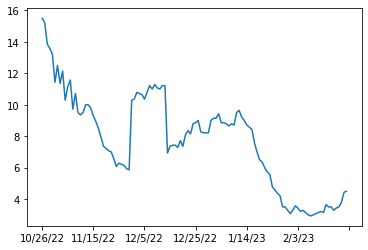

In [6]:
i_rolling.plot()
# plt.yscale('log')

In [7]:
populations_data = pd.read_csv('populations.csv')
populations = populations_data.groupby('Location').sum()

In [8]:
deaths.insert(loc=0, column='Population', value = populations['PopTotal'])
deaths = deaths.loc[deaths['Population'] > 500]

In [9]:
N = 7

In [10]:
deaths['NdayIncrement'] = (deaths.iloc[:,-1] - deaths.iloc[:,-1-N])
deaths['NdayAverage'] = deaths['NdayIncrement'] / N

In [11]:
deaths['NdayIncrementPer10M'] = deaths['NdayIncrement'] / deaths['Population'] * 10000
deaths['NdayAveragePer10M'] = deaths['NdayAverage'] / deaths['Population'] * 10000

In [12]:
result = deaths.loc[:,['Population', 'NdayIncrement', 'NdayAverage', 'NdayIncrementPer10M' ,'NdayAveragePer10M']]

In [13]:
top = result.sort_values(by=['NdayAveragePer10M'], ascending=False).head(50)
top.insert(0, "Rank", range(1, 1 + len(top)))
top
# top.loc['Israel']

,Rank,Population,NdayIncrement,NdayAverage,NdayIncrementPer10M,NdayAveragePer10M
Country/Region,,,,,,
US,1,331003.0,3006,429.428571,90.814887,12.973555
Australia,2,25500.0,195,27.857143,76.470588,10.924370
Sweden,3,10099.0,71,10.142857,70.303990,10.043427
Finland,4,5541.0,38,5.428571,68.579679,9.797097
Lithuania,5,2722.0,18,2.571429,66.127847,9.446835
Japan,6,126476.0,787,112.428571,62.225244,8.889321
Estonia,7,1327.0,8,1.142857,60.286360,8.612337
Canada,8,37742.0,222,31.714286,58.820412,8.402916
Latvia,9,1886.0,11,1.571429,58.324496,8.332071


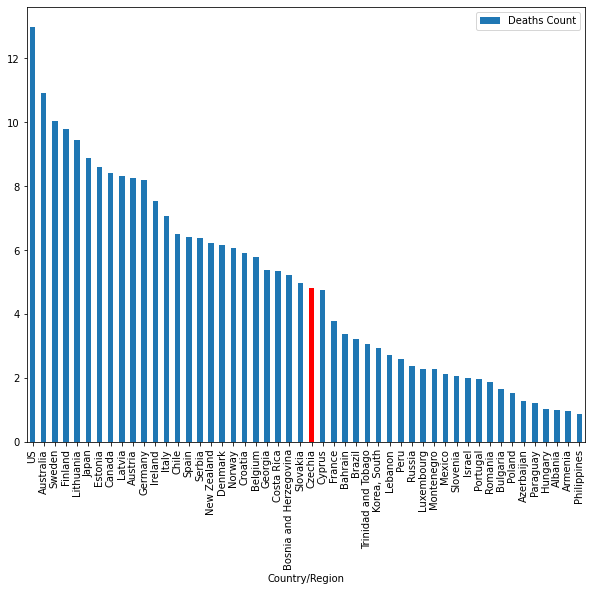

In [14]:
top.rename(columns = {'NdayAveragePer10M':'Deaths Count'}, inplace = True)
pl = top.plot(kind='bar', y='Deaths Count', figsize=(10,8))
pl

# highlight Czechia
pos = top.index.get_loc("Czechia")
pl.patches[pos].set_facecolor('#ff0000')